Importing The libraries

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

Loading the Dataset

In [2]:
# 1. Load and Prepare
df = sns.load_dataset('tips')

Using only key numeric features to make this easier

In [3]:
X = df[['total_bill', 'size']]
y = df['tip']

Scaling

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Splitting the data into train & test data

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

Intializing the regressor

In [6]:
# 3. Initialize SGDRegressor (This uses Gradient Descent)
# max_iter is the number of 'steps' down the mountain
# eta0 is the starting learning rate
sgd = SGDRegressor(max_iter=1000, eta0=0.01, random_state=42)

Visualizing and Evaluating the Descent

In [9]:
model = SGDRegressor(eta0=0.01, learning_rate='constant')
errors = []

for epoch in range(1, 101):
    model.partial_fit(X_train, y_train) # Take one step
    y_curr_pred = model.predict(X_train)
    errors.append(mean_squared_error(y_train, y_curr_pred))

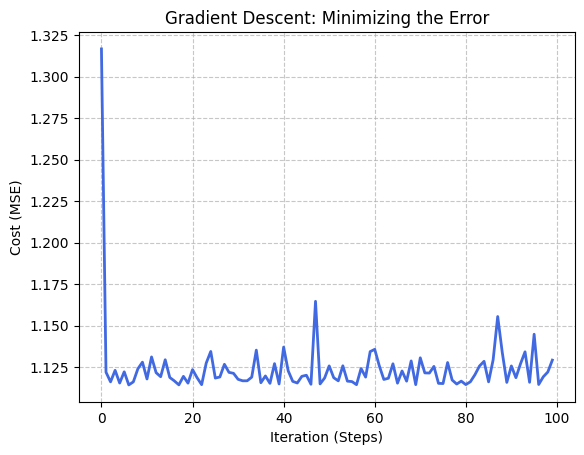

In [10]:
plt.plot(errors, color='royalblue', lw=2)
plt.xlabel('Iteration (Steps)')
plt.ylabel('Cost (MSE)')
plt.title('Gradient Descent: Minimizing the Error')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()